<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/SQL/SESI%C3%93N_6_CURSORES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

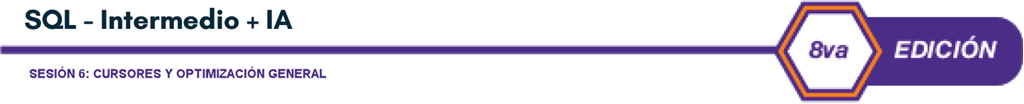

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">¿Qué son los cursores?</font>**

</td>
</tr>
</table>

Los cursores en SQL Server son estructuras que permiten recorrer y manipular filas de resultados de una consulta SQL de forma secuencial.

Son útiles cuando necesitas realizar operaciones fila por fila, lo cual no se puede lograr fácilmente con un solo comando SQL.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">¿Para qué sirven los cursores?</font>**

</td>
</tr>
</table>

>* **Tratamiento Fila por Fila**: Permiten realizar operaciones en cada fila de un conjunto, como realizar cálculos, actualizaciones o validar datos individualmente.
>* **Iteración sobre Resultados**: Son útiles cuando se necesita iterar sobre un conjunto de resultados y ejecutar lógica de negocio específica para cada fila.
>* **Acciones Complejas**: Facilitan la ejecución de lógica compleja que no se puede expresar fácilmente mediante consultas SQL estándar.
>* **Integración con Procedimientos Almacenados**: Permiten crear procedimientos que requieren una lógica de procesamiento más compleja y en la que se necesite manipular datos fila por fila.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Diferencia entre procesamiento por conjuntos (set-based) y por filas (row-by-row)</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF"> Procesamiento por Conjuntos (Set-Based)</font>**

</td>
</tr>
</table>

>* **Operaciones sobre Conjuntos**:
    * Las consultas afectan múltiples filas a la vez en lugar de una por una.
    * Utiliza operaciones como SELECT, INSERT, UPDATE, y DELETE para trabajar sobre conjuntos completos de datos.

>* **Eficiencia**:
    * Generalmente más eficiente en términos de rendimiento, ya que las bases de datos están diseñadas para optimizar operaciones sobre conjuntos.
    * Aprovecha índices y optimización de consultas, lo que resulta en un uso más eficiente de recursos.

>* **Legibilidad**:
    * A menudo más conciso y fácil de mantener, lo que facilita el entendimiento del propósito de la consulta.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Procesamiento por Filas (Row-By-Row)</font>**

</td>
</tr>
</table>

>* **Operaciones Individuales**:
    * Se procesan fila por fila, lo que implica iterar sobre cada registro individualmente.
    * Ideal para situaciones en las que se requiere lógica compleja específica para cada fila.

>* **Eficiencia**:
    * Generalmente menos eficiente, ya que involucra más operaciones y menos optimización, lo que puede llevar a un mayor uso de recursos.
    * Puede resultar en un rendimiento degradado, especialmente con grandes conjuntos de datos.

>* **Flexibilidad**:
    * Permite una lógica más compleja, como cálculos avanzados o condiciones específicas que son difíciles de expresar en una sola consulta de conjunto.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">¿Cuándo no usar cursores (y cuándo sí, en casos justificados)?</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">¿Cuándo Usar Cursores (Casos Justificados)?</font>**

</td>
</tr>
</table>

>* **Lógica Compleja por Fila**: Cuando la operación requiere lógica diferente para cada fila y no puede ser fácilmente expresada en SQL. Por ejemplo, cálculos que dependen de resultados previos.
>* **Interacción con Aplicaciones Exteriores**: A veces, se necesita interactuar con aplicaciones externas o APIs donde la lógica debe ser aplicada fila por fila.
>* **Operaciones Dependientes de Filas Previas**: Cuando las decisiones de procesamiento en una fila dependen de las filas que se procesaron anteriormente.
>* **Carga y Transformación de Datos (ETL)**: En procesos de Extract, Transform, Load (ETL) donde cada fila requiere transformaciones específicas que no se pueden realizar de manera eficiente mediante operaciones de conjunto.
>* **Mantenimiento Específico**: Si trabajas en mantenimiento de bases de datos, como migraciones, donde las acciones sobre cada fila dependen del estado actual de la base de datos.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">¿Cuándo No Usar Cursores?</font>**

</td>
</tr>
</table>

>* **Grandes Conjuntos de Datos**: Evita el uso de cursores con grandes volúmenes de datos, ya que pueden resultar en un rendimiento deficiente debido a la iteración fila por fila.
>* **Tareas Simples**: Para operaciones simples que pueden ser realizadas con consultas basadas en conjuntos (como UPDATE, INSERT, o DELETE), no es necesario recurrir a un cursor.
>* **Operaciones de Agregación**: Cuando necesitas realizar cálculos agregados o resúmenes, como SUM, AVG, o COUNT, siempre es mejor usar consultas de conjunto.
>* **Transformaciones Masivas**: Evita los cursores para transformaciones de datos que pueden ser realizadas en bloque con una sola consulta.
>* **Condiciones Iterativas Simples**: Si el resultado puede lograrse usando cláusulas CASE, subconsultas, o JOIN, opta por esos métodos.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Tipos de Cursores</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">STATIC</font>**

</td>
</tr>
</table>

Un cursor estático en SQL Server es un tipo de cursor que crea una copia fija de los datos recuperados por una consulta.

Un cursor estático crea una copia temporal de los datos. Los cambios en la base de datos NO se reflejan en el cursor.



```
USE Northwind
GO
DECLARE ucr_producto_estatico CURSOR STATIC FOR
SELECT
	[ProductID]
	,[ProductName]
	,[UnitPrice]
	,[UnitsInStock]
	,[Discontinued]
FROM [dbo].[Products]
WHERE UnitPrice > 20
ORDER BY UnitPrice;

OPEN ucr_producto_estatico;

FETCH NEXT FROM ucr_producto_estatico;


CLOSE ucr_producto_estatico;
DEALLOCATE ucr_producto_estatico;
```





```
USE Northwind
GO
DECLARE @ProductID			int;
DECLARE @ProductName		nvarchar(40);
DECLARE @UnitPrice			money;
DECLARE @UnitsInStock		smallint;
DECLARE @Discontinued		bit;

DECLARE ucr_producto_estatico CURSOR STATIC FOR
SELECT
	[ProductID]
	,[ProductName]
	,[UnitPrice]
	,[UnitsInStock]
	,[Discontinued]
FROM [dbo].[Products]
WHERE UnitPrice > 20
ORDER BY UnitPrice;

OPEN ucr_producto_estatico;

FETCH NEXT FROM ucr_producto_estatico
INTO
	@ProductID,
	@ProductName,
	@UnitPrice,
	@UnitsInStock,
	@Discontinued;

PRINT CONCAT
(
	@ProductID, SPACE(3),
	@ProductName, SPACE(3),
	@UnitPrice, SPACE(3),
	@UnitsInStock, SPACE(3),
	@Discontinued
)

CLOSE ucr_producto_estatico;
DEALLOCATE ucr_producto_estatico;
```





```
USE Northwind
GO
DECLARE @ProductID			int;
DECLARE @ProductName		nvarchar(40);
DECLARE @UnitPrice			money;
DECLARE @UnitsInStock		smallint;
DECLARE @Discontinued		bit;

DECLARE @cntFila			int = 0;

DECLARE ucr_producto_estatico CURSOR STATIC READ_ONLY FOR
SELECT
	[ProductID]
	,[ProductName]
	,[UnitPrice]
	,[UnitsInStock]
	,[Discontinued]
FROM [dbo].[Products]
WHERE UnitPrice > 20
ORDER BY UnitPrice;

OPEN ucr_producto_estatico;

FETCH NEXT FROM ucr_producto_estatico
INTO
	@ProductID,
	@ProductName,
	@UnitPrice,
	@UnitsInStock,
	@Discontinued;
PRINT REPLICATE('─', 97);
PRINT CONCAT
	(
		LEFT(CAST('ID' AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
		LEFT(CAST('CÓDIGO' AS VARCHAR(6)) + SPACE(6), 6), SPACE(3),
		LEFT(CAST('PRODUCTO' AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
		RIGHT(SPACE(12) + CAST('PRECIO' AS VARCHAR(12)), 12), SPACE(3),
		RIGHT(SPACE(12) + CAST('STOCK' AS VARCHAR(5)), 5), SPACE(3),
		'DESCONTINUADO'
	);
PRINT REPLICATE('─', 97);
WHILE @@FETCH_STATUS = 0
BEGIN
	SET @cntFila += 1

	PRINT CONCAT
	(
		LEFT(CAST(@cntFila AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
		LEFT(CAST(@ProductID AS VARCHAR(5)) + SPACE(6), 6), SPACE(3),
		LEFT(CAST(@ProductName AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
		RIGHT(SPACE(12) + '$' + CAST(@UnitPrice AS VARCHAR(12)), 12), SPACE(3),
		RIGHT(SPACE(12) + CAST(@UnitsInStock AS VARCHAR(5)), 5), SPACE(3),
		CASE @Discontinued WHEN 1 THEN 'SI' ELSE 'NO' END
	);

	FETCH NEXT FROM ucr_producto_estatico
	INTO
		@ProductID,
		@ProductName,
		@UnitPrice,
		@UnitsInStock,
		@Discontinued;
END

CLOSE ucr_producto_estatico;
DEALLOCATE ucr_producto_estatico;
PRINT REPLICATE('─', 86);
PRINT CONCAT('Total de productos encontrados: ', @cntFila);
print REPLICATE('─', 86);


```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">KEYSET</font>**

</td>
</tr>
</table>

Mantiene un conjunto de claves. Detecta cambios en los valores pero NO detecta nuevas filas insertadas.



```
USE Northwind
GO
DECLARE @ProductID          int;
DECLARE @ProductName        nvarchar(40);
DECLARE @UnitPrice          money;
DECLARE @UnitsInStock       smallint;
DECLARE @Discontinued       bit;

DECLARE @cntFila            int = 0;

DECLARE ucr_producto_keyset CURSOR KEYSET READ_ONLY FOR
SELECT
    [ProductID]
    ,[ProductName]
    ,[UnitPrice]
    ,[UnitsInStock]
    ,[Discontinued]
FROM [dbo].[Products]
WHERE UnitPrice > 20
ORDER BY UnitPrice;

OPEN ucr_producto_keyset;

FETCH NEXT FROM ucr_producto_keyset
INTO
    @ProductID,
    @ProductName,
    @UnitPrice,
    @UnitsInStock,
    @Discontinued;
PRINT REPLICATE('─', 97);
PRINT CONCAT
    (
        LEFT(CAST('ID' AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
        LEFT(CAST('CÓDIGO' AS VARCHAR(6)) + SPACE(6), 6), SPACE(3),
        LEFT(CAST('PRODUCTO' AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
        RIGHT(SPACE(12) + CAST('PRECIO' AS VARCHAR(12)), 12), SPACE(3),
        RIGHT(SPACE(12) + CAST('STOCK' AS VARCHAR(5)), 5), SPACE(3),
        'DESCONTINUADO'
    );
PRINT REPLICATE('─', 97);
WHILE @@FETCH_STATUS = 0
BEGIN
    SET @cntFila += 1

    PRINT CONCAT
    (
        LEFT(CAST(@cntFila AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
        LEFT(CAST(@ProductID AS VARCHAR(5)) + SPACE(6), 6), SPACE(3),
        LEFT(CAST(@ProductName AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
        RIGHT(SPACE(12) + '$' + CAST(@UnitPrice AS VARCHAR(12)), 12), SPACE(3),
        RIGHT(SPACE(12) + CAST(@UnitsInStock AS VARCHAR(5)), 5), SPACE(3),
        CASE @Discontinued WHEN 1 THEN 'SI' ELSE 'NO' END
    );

    FETCH NEXT FROM ucr_producto_keyset
    INTO
        @ProductID,
        @ProductName,
        @UnitPrice,
        @UnitsInStock,
        @Discontinued;
END

CLOSE ucr_producto_keyset;
DEALLOCATE ucr_producto_keyset;
PRINT REPLICATE('─', 86);
PRINT CONCAT('Total de productos encontrados: ', @cntFila);
print REPLICATE('─', 86);
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">DINAMIC</font>**

</td>
</tr>
</table>

Refleja todos los cambios realizados en la base de datos (inserciones, actualizaciones, eliminaciones).



```
USE Northwind
GO
DECLARE @ProductID			int;
DECLARE @ProductName		nvarchar(40);
DECLARE @UnitPrice			money;
DECLARE @UnitsInStock		smallint;
DECLARE @Discontinued		bit;

DECLARE @cntFila			int = 0;

DECLARE ucr_producto_dynamic CURSOR DYNAMIC FOR
SELECT
	[ProductID]
	,[ProductName]
	,[UnitPrice]
	,[UnitsInStock]
	,[Discontinued]
FROM [dbo].[Products]
WHERE UnitPrice > 20
ORDER BY UnitPrice;

OPEN ucr_producto_dynamic;

FETCH NEXT FROM ucr_producto_dynamic
INTO
	@ProductID,
	@ProductName,
	@UnitPrice,
	@UnitsInStock,
	@Discontinued;
PRINT REPLICATE('─', 97);
PRINT CONCAT
	(
		LEFT(CAST('ID' AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
		LEFT(CAST('CÓDIGO' AS VARCHAR(6)) + SPACE(6), 6), SPACE(3),
		LEFT(CAST('PRODUCTO' AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
		RIGHT(SPACE(12) + CAST('PRECIO' AS VARCHAR(12)), 12), SPACE(3),
		RIGHT(SPACE(12) + CAST('STOCK' AS VARCHAR(5)), 5), SPACE(3),
		'DESCONTINUADO'
	);
PRINT REPLICATE('─', 97);
WHILE @@FETCH_STATUS = 0
BEGIN
	SET @cntFila += 1

	PRINT CONCAT
	(
		LEFT(CAST(@cntFila AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
		LEFT(CAST(@ProductID AS VARCHAR(5)) + SPACE(6), 6), SPACE(3),
		LEFT(CAST(@ProductName AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
		RIGHT(SPACE(12) + '$' + CAST(@UnitPrice AS VARCHAR(12)), 12), SPACE(3),
		RIGHT(SPACE(12) + CAST(@UnitsInStock AS VARCHAR(5)), 5), SPACE(3),
		CASE @Discontinued WHEN 1 THEN 'SI' ELSE 'NO' END
	);

	FETCH NEXT FROM ucr_producto_dynamic
	INTO
		@ProductID,
		@ProductName,
		@UnitPrice,
		@UnitsInStock,
		@Discontinued;
END

CLOSE ucr_producto_dynamic;
DEALLOCATE ucr_producto_dynamic;
PRINT REPLICATE('─', 86);
PRINT CONCAT('Total de productos encontrados: ', @cntFila);
PRINT REPLICATE('─', 86);
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">FORWARD_ONLY</font>**

</td>
</tr>
</table>

Solo permite desplazamiento hacia adelante. Es el **tipo por defecto** y el más rápido.



```
USE Northwind
GO
DECLARE @ProductID			int;
DECLARE @ProductName		nvarchar(40);
DECLARE @UnitPrice			money;
DECLARE @UnitsInStock		smallint;
DECLARE @Discontinued		bit;

DECLARE @cntFila			int = 0;

DECLARE ucr_producto_forward_only CURSOR FORWARD_ONLY FOR
SELECT
	[ProductID]
	,[ProductName]
	,[UnitPrice]
	,[UnitsInStock]
	,[Discontinued]
FROM [dbo].[Products]
WHERE UnitPrice > 20
ORDER BY UnitPrice;

OPEN ucr_producto_forward_only;

FETCH NEXT FROM ucr_producto_forward_only
INTO
	@ProductID,
	@ProductName,
	@UnitPrice,
	@UnitsInStock,
	@Discontinued;
PRINT REPLICATE('─', 97);
PRINT CONCAT
	(
		LEFT(CAST('ID' AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
		LEFT(CAST('CÓDIGO' AS VARCHAR(6)) + SPACE(6), 6), SPACE(3),
		LEFT(CAST('PRODUCTO' AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
		RIGHT(SPACE(12) + CAST('PRECIO' AS VARCHAR(12)), 12), SPACE(3),
		RIGHT(SPACE(12) + CAST('STOCK' AS VARCHAR(5)), 5), SPACE(3),
		'DESCONTINUADO'
	);
PRINT REPLICATE('─', 97);
WHILE @@FETCH_STATUS = 0
BEGIN
	SET @cntFila += 1

	PRINT CONCAT
	(
		LEFT(CAST(@cntFila AS VARCHAR(3)) + SPACE(3), 3), SPACE(3),
		LEFT(CAST(@ProductID AS VARCHAR(5)) + SPACE(6), 6), SPACE(3),
		LEFT(CAST(@ProductName AS VARCHAR(40)) + SPACE(40), 40), SPACE(3),
		RIGHT(SPACE(12) + '$' + CAST(@UnitPrice AS VARCHAR(12)), 12), SPACE(3),
		RIGHT(SPACE(12) + CAST(@UnitsInStock AS VARCHAR(5)), 5), SPACE(3),
		CASE @Discontinued WHEN 1 THEN 'SI' ELSE 'NO' END
	);

	FETCH NEXT FROM ucr_producto_forward_only
	INTO
		@ProductID,
		@ProductName,
		@UnitPrice,
		@UnitsInStock,
		@Discontinued;
END

CLOSE ucr_producto_forward_only;
DEALLOCATE ucr_producto_forward_only;
PRINT REPLICATE('─', 86);
PRINT CONCAT('Total de productos encontrados: ', @cntFila);
PRINT REPLICATE('─', 86);
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Comparación de los Tipos de Cursores</font>**

</td>
</tr>
</table>

|Tipo|Detecta cambios|Detecta Inserciones|Detecta Eliminaciones|Rendimiento|
|---|---|---|---|---|
|STATIC|❌ No|❌ No|❌ No|Medio|
|KEYSET|✅ Si|❌ No|✅ Si|Medio-Bajo|
|DYNAMIC|✅ SI|✅|✅|Medio-Bajo|
|FORWARD_ONLY|Depende|Depende|Depende|Alto|

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">FETCH FIRSH (Ir al primer registro)</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO
DECLARE @cnt INT = 0;

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);


DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;

FETCH NEXT FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0
BEGIN
    SET @cnt += 1;
    IF @cnt = 4 BREAK
    PRINT CONCAT
            (
                'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
                SPACE(2),
                LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
                @Title
            );
    
    FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;
END

PRINT REPLICATE('─', 55);

FETCH FIRST FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

        PRINT CONCAT
            (
                'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
                SPACE(2),
                LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
                @Title
            );
PRINT REPLICATE('─', 55);
CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO


```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">FETCH LAST (Ir al último registro)</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO
DECLARE @cnt INT = 0;

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);


DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;

FETCH NEXT FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0
BEGIN
    SET @cnt += 1;
    IF @cnt = 4 BREAK
    PRINT CONCAT
            (
                'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
                SPACE(2),
                LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
                @Title
            );
    
    FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;
END

PRINT REPLICATE('─', 55);

FETCH LAST FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

        PRINT CONCAT
            (
                'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
                SPACE(2),
                LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
                @Title
            );
PRINT REPLICATE('─', 55);
CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">FETCH PRIOR (Retroceder al registro anterior)</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO
DECLARE @cnt INT = 0;

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);


DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0
BEGIN
    SET @cnt += 1;
    IF @cnt = 4 BREAK

    FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;
    PRINT CONCAT
            (
                'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
                SPACE(2),
                LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
                @Title
            );
    
END

PRINT REPLICATE('─', 55);

FETCH PRIOR FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

    PRINT CONCAT
        (
            'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
            SPACE(2),
            LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
            @Title
        );
    PRINT REPLICATE('─', 55);
CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF"> FETCH ABSOLUTE (Ir a una posición específica)</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO
DECLARE @cnt INT = 0;

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);


DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;
FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0
BEGIN
    SET @cnt += 1;

    PRINT CONCAT
    (
        'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
        SPACE(2),
        LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
        @Title
    );

    FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;
END

PRINT REPLICATE('─', 55);

FETCH ABSOLUTE 5 FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

    PRINT CONCAT
        (
            'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
            SPACE(2),
            LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
            @Title
        );
    PRINT REPLICATE('─', 55);
CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">FETCH RELATIVE (Mover relativamente desde la posición actual)</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO
DECLARE @cnt INT = 0;

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);


DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;
FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0
BEGIN
    SET @cnt += 1;

    PRINT CONCAT
    (
        'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
        SPACE(2),
        LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
        @Title
    );
    IF @cnt = 4 BREAK
    FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;
END

PRINT REPLICATE('─', 55);

FETCH RELATIVE 3 FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

    PRINT CONCAT
        (
            'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
            SPACE(2),
            LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
            @Title
        );
    PRINT REPLICATE('─', 55);

    ----------------------------------------------------------------------------------------------------------------
    PRINT REPLICATE('─', 55);

FETCH RELATIVE -5 FROM ucr_empleado
INTO
    @EmployeeID,
    @LastName,
    @FirstName,
    @Title,
    @TitleOfCourtesy;

    PRINT CONCAT
        (
            'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
            SPACE(2),
            LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
            @Title
        );
    PRINT REPLICATE('─', 55);
CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Manejo de errores en cursores</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);

DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;
FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0
BEGIN
    BEGIN TRY
        PRINT CONCAT
        (
            'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
            SPACE(2),
            LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
            @Title
        );

        IF @EmployeeID > 5
        BEGIN
            RAISERROR('Demasiados empleados.', 16, 1);
        END
        FETCH NEXT FROM ucr_empleado
        INTO
            @EmployeeID,
            @LastName,
            @FirstName,
            @Title,
            @TitleOfCourtesy;
    END TRY
    BEGIN CATCH
        PRINT '';
        PRINT CONCAT('Error: ', ERROR_MESSAGE());
        BREAK
    END CATCH
END

CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Bucle con limites de registros procesados (TOP N)</font>**

</td>
</tr>
</table>



```
USE [Northwind]
GO

DECLARE @EmployeeID         INT;
DECLARE @LastName           NVARCHAR(20);
DECLARE @FirstName          NVARCHAR(10);
DECLARE @Title              NVARCHAR(30);
DECLARE @TitleOfCourtesy    NVARCHAR(25);

DECLARE @cnt                INT = 1;
DECLARE @maximo             INT = 5;

DECLARE ucr_empleado CURSOR SCROLL FOR
SELECT
    [EmployeeID]
    ,[LastName]
    ,[FirstName]
    ,[Title]
    ,[TitleOfCourtesy]
FROM [dbo].[Employees];

OPEN ucr_empleado;
FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;

PRINT REPLICATE('─', 55);
PRINT CONCAT
            (
                'ID  ',
                SPACE(2),
                LEFT('EMPLEADO' + SPACE(25), 25),
                'CARGO'
            );
PRINT REPLICATE('─', 55);
WHILE @@FETCH_STATUS = 0 AND @cnt <= @maximo
BEGIN
    PRINT CONCAT
    (
        'E'+RIGHT('000' + LTRIM(@EmployeeID), 3),
        SPACE(2),
        LEFT(LTRIM(@TitleOfCourtesy) + SPACE(1) + LTRIM(@LastName) + ', ' + LTRIM(@FirstName) + SPACE(25), 25),
        @Title
    );
    SET @cnt += 1;
    FETCH NEXT FROM ucr_empleado
    INTO
        @EmployeeID,
        @LastName,
        @FirstName,
        @Title,
        @TitleOfCourtesy;
END

CLOSE ucr_empleado;
DEALLOCATE ucr_empleado;

GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Cursor Anidado</font>**

</td>
</tr>
</table>



```
USE pvl;
GO
CREATE OR ALTER PROCEDURE usp_comite_consulta
(
	@cod_com_si smallint
)
AS
BEGIN
	DECLARE @nom_cen_aco_vc		varchar(30);
	DECLARE @nom_pue_vc			varchar(50);
	DECLARE @nom_com_vc			varchar(40);

	DECLARE @pat_ben_vc				varchar(40);
	DECLARE @mat_ben_vc				varchar(40);
	DECLARE @nom_ben_vc				varchar(35);
	DECLARE @cod_tip_doc_ben_ti		tinyint;
	DECLARE @dni_ben_ch				char(8);
	DECLARE @Edad					int;
	DECLARE @Semana					int;
	DECLARE @Lactancia				int;

	DECLARE ucr_comite CURSOR FOR
	SELECT
		ca.nom_cen_aco_vc,
		p.nom_pue_vc,
		c.nom_com_vc
	FROM CentroAcopio ca
	INNER JOIN Pueblo p
	ON ca.cod_cen_aco_ti = p.cod_cen_aco_ti
	INNER JOIN Comite c
	ON p.cod_pue_si = c.cod_pue_si
	WHERE cod_com_si = @cod_com_si;

	OPEN ucr_comite;

	FETCH NEXT FROM ucr_comite
	INTO
		@nom_cen_aco_vc,
		@nom_pue_vc,
		@nom_com_vc;

	PRINT 'CENTRO DE ACOPIO: ' + @nom_cen_aco_vc;
	PRINT '          PUEBLO: ' + @nom_pue_vc;
	PRINT '          COMITÉ: ' + @nom_com_vc;

	CLOSE ucr_comite;
	DEALLOCATE ucr_comite;

	DECLARE ucr_beneficiario CURSOR FOR

	SELECT
      [pat_ben_vc]
      ,[mat_ben_vc]
      ,[nom_ben_vc]
      ,[cod_tip_doc_ben_ti]
      ,[dni_ben_ch]
      ,CONVERT(INT, DATEDIFF(DAY,[fec_nac_ben_da], '2004-09-30')/365.256363004) AS Edad
      ,CONVERT(INT, DATEDIFF(DAY,[fec_emb_ben_da], '2004-09-30')/7) AS Semana
      ,CONVERT(INT, DATEDIFF(DAY,[fec_lac_ben_da], '2004-09-30')/365.256363004) AS Lactancia
  FROM [dbo].[Beneficiario]
  WHERE cod_com_si = @cod_com_si;

	OPEN ucr_beneficiario;

	FETCH NEXT FROM ucr_beneficiario
	INTO
	@pat_ben_vc,
	@mat_ben_vc,
	@nom_ben_vc,
	@cod_tip_doc_ben_ti,
	@dni_ben_ch,
	@Edad,
	@Semana,
	@Lactancia;

	WHILE @@FETCH_STATUS = 0
	BEGIN
		PRINT CONCAT
		(
			@pat_ben_vc,
			@mat_ben_vc,
			@nom_ben_vc,
			@cod_tip_doc_ben_ti,
			@dni_ben_ch,
			@Edad,
			@Semana,
			@Lactancia
		);

		FETCH NEXT FROM ucr_beneficiario
		INTO
		@pat_ben_vc,
		@mat_ben_vc,
		@nom_ben_vc,
		@cod_tip_doc_ben_ti,
		@dni_ben_ch,
		@Edad,
		@Semana,
		@Lactancia;

	END


	CLOSE ucr_beneficiario;
	DEALLOCATE ucr_beneficiario;



	RETURN 0
END
GO
usp_comite_consulta 123
```

